# House Price Prediction: Modeling Nonlinear Relationships

The previous project revealed a nonlinear relationship between `HouseAge` and `SalePrice`, which linear model could not fully capture, motivating a dedicated investigation into nonlinear modeling techniques.

This project focuses on analyzing feature-target relationships and comparing modeling approaches. It builds directly on the previous pipeline, using the same cleaned dataset. 

The existing Lasso model (α=0.00066) serves as the baseline, with a validation RMSE of 0.1162 on log-transformed prices and a train/validation gap of 0.0120, indicating good generalization. The goal is to evaluate whether nonlinear transformations of the selected features can improve on this baseline.

| Baseline model | Train RMSE | Validation RMSE | Gap |
|-------|-----------|-----------------|-----|
| Lasso (α=0.00066) | 0.1040 | 0.1160 | 0.0120 |

In [1]:
BASELINE_RESULTS = {
    'Train RMSE': 0.1040,
    'Validation RMSE': 0.1160,
    'Gap': 0.0120
}

In [2]:
import csv
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from pathlib import Path

# Cleaned datasets from the linear models project are used directly
# Raw data preprocessing is documented in 01_linear_models/house_price_modeling.ipynb

ROOT = Path.cwd().parent
CLEAN_TRAIN_DATA_PATH = ROOT / 'data' / 'processed' / 'train_clean.csv'
CLEAN_TEST_DATA_PATH = ROOT/ 'data' / 'processed' / 'test_clean.csv'

In [4]:
df_test = pd.read_csv(CLEAN_TEST_DATA_PATH)
df_test.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,SaleType,SaleCondition,HouseAge
0,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,WD,Normal,49
1,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,WD,Normal,52
2,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,WD,Normal,13
3,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,WD,Normal,12
4,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,WD,Normal,18


In [5]:
df_train = pd.read_csv(CLEAN_TRAIN_DATA_PATH)
df_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,SaleType,SaleCondition,SalePrice,HouseAge
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,WD,Normal,208500,5
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,WD,Normal,181500,31
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,WD,Normal,223500,7
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,WD,Abnorml,140000,91
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,WD,Normal,250000,8


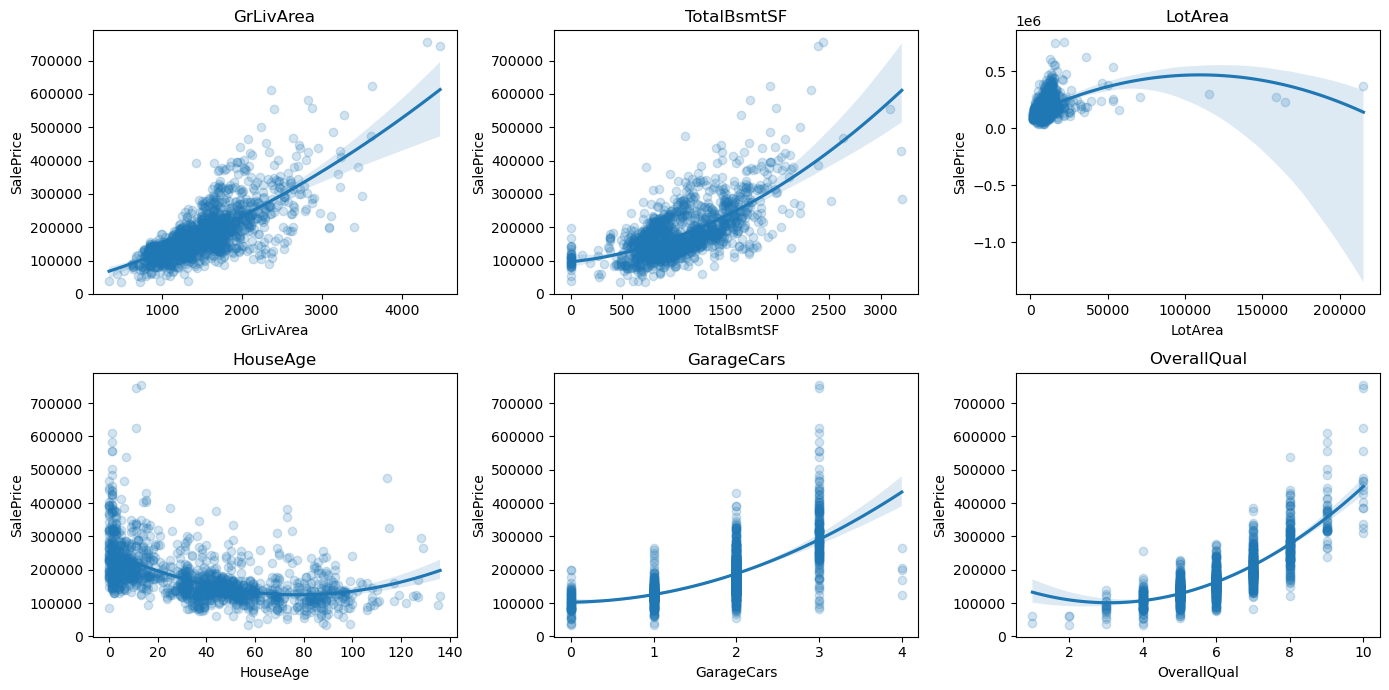

In [6]:
numeric_cols = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'HouseAge', 'GarageCars', 'OverallQual']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.regplot(data=df_train, x=col, y='SalePrice',
                order=2, ax=ax, scatter_kws={'alpha': 0.2})
    ax.set_title(col)

plt.tight_layout()
plt.show()

Based on the visual analysis, three features were selected for nonlinear modeling: `HouseAge` (U-shaped curve), `TotalBsmtSF` (accelerating trend), and `OverallQual` (stepwise pattern). 
    
For each feature, three methods will be fitted and compared:
- Polynomial Regression
- Step Functions
- Regression Splines
        
Models will be evaluated on RMSE, bias-variance tradeoff, and interpretability.

## `HouseAge` vs `SalePrice`
### `HouseAge` vs `SalePrice`: Polynomial Regression

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

In [8]:
df_train['HouseAge'].describe()

count    1458.000000
mean       36.598080
std        30.240565
min         0.000000
25%         8.000000
50%        35.000000
75%        54.000000
max       136.000000
Name: HouseAge, dtype: float64

In [9]:
X = df_train[['HouseAge']]
y = np.log1p(df_train['SalePrice'])

X_train_age, X_val_age, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=123)

In [10]:
results_age = []

for degree in [2, 3, 4, 5]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_age)
    X_val_poly = poly.transform(X_val_age)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train_poly)))
    val_rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val_poly)))
    
    results_age.append({
        'Degree': degree,
        'Train RMSE': train_rmse,
        'Validation RMSE': val_rmse,
        'Gap': val_rmse - train_rmse
    })

pd.DataFrame(results_age).style.format('{:.4f}', subset=['Train RMSE', 'Validation RMSE', 'Gap']).hide(axis='index')

Degree,Train RMSE,Validation RMSE,Gap
2,0.3075,0.3100,0.0025
3,0.3075,0.3101,0.0026
4,0.3075,0.3100,0.0025
5,0.3073,0.3106,0.0033


> Note: in the previous project, degree 3 was selected based on a visual fit to raw `SalePrice`. Here, the target is `log(SalePrice)`, which makes large price differences appear smaller — the U-shape becomes shallower and degree 2 captures it equally well. 
>    
> RMSE differences between degrees are negligible, so degree 2 is preferred: simpler model, same performance.

In [11]:
poly_age_train_rmse = 0.3075
poly_age_val_rmse = 0.3100
poly_age_gap = 0.0025

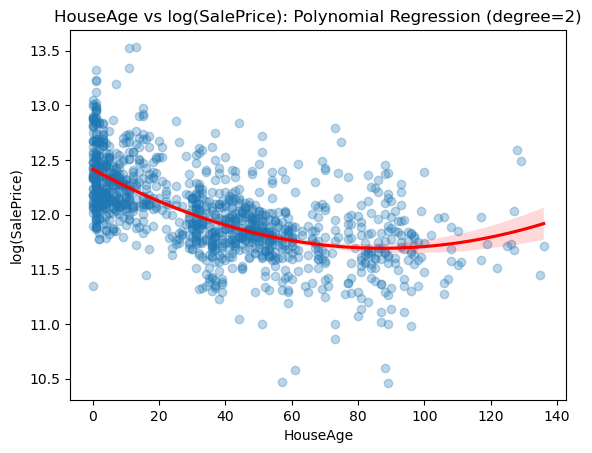

In [12]:
plot_df = X_train_age.copy()
plot_df['y'] = y_train
sns.regplot(plot_df, x='HouseAge', y='y', scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'}, order=2)
plt.ylabel('log(SalePrice)')
plt.title('HouseAge vs log(SalePrice): Polynomial Regression (degree=2)')
plt.show()

Polynomial regression (degree=2) captures the U-shaped relationship between `HouseAge` and `log(SalePrice)`: prices decrease until around 80 years, then recover. 
    
Interpretability is high: the coefficients directly describe the direction and curvature of the relationship, making it easy to explain to a non-technical audience.

### `HouseAge` vs `SalePrice`: Step Functions

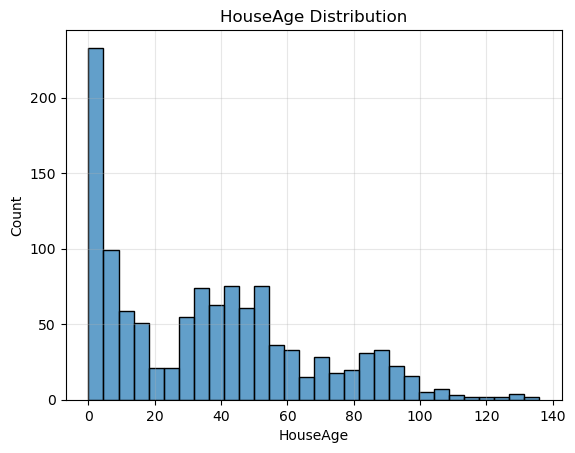

In [13]:
# HouseAge distribution
sns.histplot(X_train_age, x='HouseAge', bins=30, alpha=0.7)
plt.title('HouseAge Distribution')
plt.grid(True, alpha=0.3)

In [14]:
bins = [0, 10, 20, 30, 40, 50, 60, 80, 100, 140]

X_train_cut = pd.cut(X_train_age['HouseAge'], bins=bins)
X_val_cut = pd.cut(X_val_age['HouseAge'], bins=bins)

print(X_train_cut.value_counts().sort_index())

HouseAge
(0, 10]       300
(10, 20]      102
(20, 30]       60
(30, 40]      164
(40, 50]      148
(50, 60]      121
(60, 80]       82
(80, 100]     115
(100, 140]     24
Name: count, dtype: int64


`HouseAge` was binned into 9 intervals using custom boundaries rather than KBinsDiscretizer.

Manual binning allows more informed decisions about where to place the cuts, which is particularly important since equal-width intervals would not account for the uneven distribution of house ages. 
    
Boundaries were set at decade intervals with two adjustments:
* (60, 80] was merged into a single bin due to insufficient observations in the (70, 80] range
* (100, 140] was kept as a single bin: splitting it further would result in too few observations per interval, and grouping all homes over 100 years old makes semantic sense

In [15]:
X_train_step = pd.get_dummies(X_train_cut, drop_first=True)
X_val_step = pd.get_dummies(X_val_cut, drop_first=True)

model_step = LinearRegression()
model_step.fit(X_train_step, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


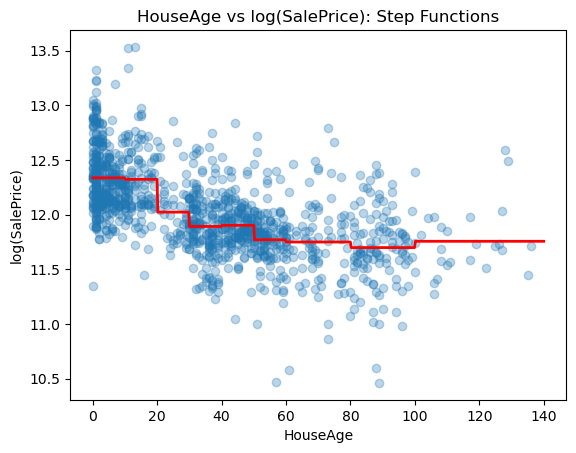

In [16]:
age_range = np.linspace(0, 140, 500)
age_range_cut = pd.cut(age_range, bins=bins)
age_range_step = pd.get_dummies(age_range_cut, drop_first=True)

plt.scatter(X_train_age, y_train, alpha=0.3)
plt.plot(age_range, model_step.predict(age_range_step), color='red', linewidth=2)
plt.xlabel('HouseAge')
plt.ylabel('log(SalePrice)')
plt.title('HouseAge vs log(SalePrice): Step Functions')
plt.show()

Step functions capture the general downward trend and show a slight price recovery after 100 years, which aligns with the U-shape observed in EDA.

However, the shape of the curve is directly determined by bin boundaries. The plateau after 100 years reflects the decision to merge all older homes into a single bin due to insufficient data, which was a justified choice.

Interpretability is high: each bin has a direct, self-contained meaning.

In [17]:
step_age_train_rmse = np.sqrt(mean_squared_error(y_train, model_step.predict(X_train_step)))
step_age_val_rmse = np.sqrt(mean_squared_error(y_val, model_step.predict(X_val_step)))
step_age_gap = step_age_train_rmse - step_age_val_rmse

print("Step Functions\n")
print(f"Train RMSE: {step_age_train_rmse:.4f}")
print(f"Validation RMSE: {step_age_val_rmse:.4f}")
print(f"Gap: {step_age_gap:.4f}")

Step Functions

Train RMSE: 0.3074
Validation RMSE: 0.3103
Gap: -0.0029


### `HouseAge` vs `SalePrice`: Regression Splines

In [18]:
from sklearn.preprocessing import SplineTransformer

In [19]:
results_splines = []

# Select the optimal number of knots
for n_knots in [3, 4, 5, 6, 7]:
    spline = SplineTransformer(n_knots=n_knots, degree=3, include_bias=False)
    X_train_spline = spline.fit_transform(X_train_age)
    X_val_spline = spline.transform(X_val_age)
    
    model_spline = LinearRegression()
    model_spline.fit(X_train_spline, y_train)
    
    spline_train_rmse = np.sqrt(mean_squared_error(y_train, model_spline.predict(X_train_spline)))
    spline_val_rmse = np.sqrt(mean_squared_error(y_val, model_spline.predict(X_val_spline)))
    
    results_splines.append({
        'n_knots': n_knots,
        'Train RMSE': spline_train_rmse,
        'Validation RMSE': spline_val_rmse,
        'Gap': spline_val_rmse - spline_train_rmse
    })

pd.DataFrame(results_splines).style.format('{:.4f}', subset=['Train RMSE', 'Validation RMSE', 'Gap']).hide(axis='index')

n_knots,Train RMSE,Validation RMSE,Gap
3,0.3075,0.3101,0.0026
4,0.3073,0.3108,0.0035
5,0.3070,0.3093,0.0024
6,0.3070,0.3090,0.0020
7,0.3069,0.3097,0.0028


> n_knots=6 gives the best validation RMSE (0.3090) and the smallest gap (0.0020), indicating the best balance between fit and generalization.

In [20]:
spline_age_train_rmse = 0.3070
spline_age_val_rmse = 0.3090
spline_age_gap = 0.0020

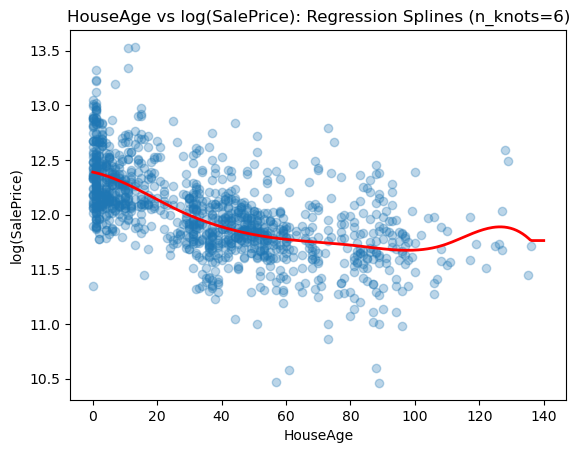

In [21]:
spline = SplineTransformer(n_knots=6, degree=3, include_bias=False)
X_train_spline = spline.fit_transform(X_train_age)
model_spline = LinearRegression()
model_spline.fit(X_train_spline, y_train)

age_range = np.linspace(0, 140, 300).reshape(-1, 1)
age_range_df = pd.DataFrame(age_range, columns=['HouseAge'])

plt.scatter(X_train_age, y_train, alpha=0.3)
plt.plot(age_range_df['HouseAge'], model_spline.predict(spline.transform(age_range_df)), color='red', linewidth=2)

plt.xlabel('HouseAge')
plt.ylabel('log(SalePrice)')
plt.title('HouseAge vs log(SalePrice): Regression Splines (n_knots=6)')
plt.show()

Regression splines (n_knots=6) produce a smooth curve that captures the general downward trend and shows a slight price recovery after 100 years, which aligns with the U-shape observed in EDA.

Regression splines produce the most visually intuitive curve: smooth, continuous, and free from artificial boundaries. 

Interpretability is nuanced: the curve itself is easy to read and explain, but the underlying coefficients correspond to abstract basis functions that overlap across the entire range and cannot be interpreted individually. If explanation without a plot is required, this becomes a limitation.

### `HouseAge`: Method Comparison

In [22]:
houseage_summary = pd.DataFrame([
    {
        'Method': 'Polynomial (degree=2)',
        'Train RMSE': poly_age_train_rmse,
        'Validation RMSE': poly_age_val_rmse,
        'Gap': poly_age_gap
    },
    {
        'Method': 'Step Functions',
        'Train RMSE': step_age_train_rmse,
        'Validation RMSE': step_age_val_rmse,
        'Gap': step_age_gap
    },
    {
        'Method': 'Splines (n_knots=6)',
        'Train RMSE': spline_age_train_rmse,
        'Validation RMSE': spline_age_val_rmse,
        'Gap': spline_age_gap
    },
])

houseage_summary.style.format('{:.4f}', subset=['Train RMSE', 'Validation RMSE', 'Gap']).hide(axis='index')

Method,Train RMSE,Validation RMSE,Gap
Polynomial (degree=2),0.3075,0.3100,0.0025
Step Functions,0.3074,0.3103,-0.0029
Splines (n_knots=6),0.3070,0.3090,0.0020


For `HouseAge`, Regression Splines (n_knots=6) outperform the other two methods across all metrics:
- lowest validation RMSE (0.3090)
- lowest gap (0.0020)
- the most visually honest representation of the relationship
    
The smooth, continuous curve captures the gradual price decline with age without imposing artificial boundaries. 
    
> Splines are selected as the preferred method for `HouseAge`.

## `OverallQual` vs `SalePrice`

In [23]:
X = df_train.drop('SalePrice', axis=1)
y = np.log1p(df_train['SalePrice'])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=123)

X_train_qual = X_train[['OverallQual']]
X_val_qual = X_val[['OverallQual']]

In [24]:
df_train['OverallQual'].describe()

count    1458.000000
mean        6.093964
std         1.376369
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: OverallQual, dtype: float64

### `OverallQaul` vs `SalePrice`: Polynomial Regression

In [25]:
results_qual = []

for degree in [2, 3, 4, 5]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_qual)
    X_val_poly = poly.transform(X_val_qual)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train_poly)))
    val_rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val_poly)))
    
    results_qual.append({
        'Degree': degree,
        'Train RMSE': train_rmse,
        'Validation RMSE': val_rmse,
        'Gap': val_rmse - train_rmse
    })

pd.DataFrame(results_qual).style.format('{:.4f}', subset=['Train RMSE', 'Validation RMSE', 'Gap']).hide(axis='index')

Degree,Train RMSE,Validation RMSE,Gap
2,0.2254,0.2336,0.0081
3,0.2249,0.2338,0.0089
4,0.2246,0.2335,0.0089
5,0.2243,0.2332,0.0089


Degree 5 achieves the lowest validation RMSE (0.2332), but the improvement over degree 2 (0.2336) is negligible — less than 0.0004. At the same time, the gap increases from 0.0081 to 0.0089, indicating slightly more overfitting.
        
> Degree 2 is preferred as the simpler model with virtually identical performance.

In [26]:
poly_qual_train_rmse = 0.2254
poly_qual_val_rmse = 0.2336
poly_qual_gap = 0.0081

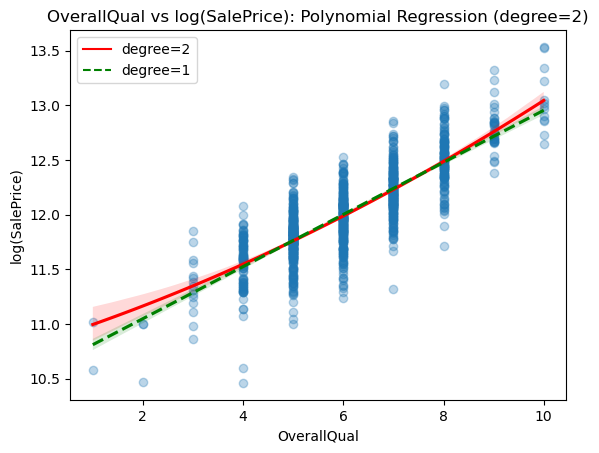

In [27]:
from matplotlib.lines import Line2D

plot_df = X_train_qual.copy()
plot_df['y'] = y_train

sns.regplot(plot_df, x='OverallQual', y='y', scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'}, order=2)
sns.regplot(plot_df, x='OverallQual', y='y', scatter=False, line_kws={'color': 'green', 'linestyle': '--', 'label': 'degree=1'}, order=1)
plt.ylabel('log(SalePrice)')
plt.title('OverallQual vs log(SalePrice): Polynomial Regression (degree=2)')
plt.legend(handles=[
    Line2D([0], [0], color='red', label='degree=2'),
    Line2D([0], [0], color='green', linestyle='--', label='degree=1')
])
plt.show()

Polynomial regression (degree=2) fits `OverallQual` well, but the curve is nearly linear. This suggests that the relationship between `OverallQual` and `SalePrice` is already close to linear on the log scale, and a more flexible method may capture the stepwise pattern better. 

Interpretability is high: the smooth curve directly shows how price increases with quality. However, a continuous curve is semantically misleading for a discrete ordinal feature.

### `OverallQual` vs `SalePrice`: Step Functions

In [28]:
# OverallQual Distributions
df_train['OverallQual'].value_counts().sort_index()

OverallQual
1       2
2       3
3      20
4     116
5     397
6     374
7     319
8     168
9      43
10     16
Name: count, dtype: int64

`OverallQual` takes discrete integer values from 1 to 10, making it a natural fit for step functions: each value represents a distinct quality rating.

Values 1 and 2 were merged with 3 into a single bin due to very few observations (2 and 3 respectively), and values 9 and 10 were merged for the same reason (43 and 16 observations respectively), resulting in 7 bins total.

In [29]:
bins = [0, 3, 4, 5, 6, 7, 8, 10]

X_train_cut_qual = pd.cut(X_train_qual['OverallQual'], bins=bins)
X_val_cut_qual = pd.cut(X_val_qual['OverallQual'], bins=bins)

print(X_train_cut_qual.value_counts().sort_index())

OverallQual
(0, 3]      20
(3, 4]      90
(4, 5]     322
(5, 6]     288
(6, 7]     260
(7, 8]     139
(8, 10]     47
Name: count, dtype: int64


In [30]:
X_train_step_qual = pd.get_dummies(X_train_cut_qual, drop_first=True)
X_val_step_qual = pd.get_dummies(X_val_cut_qual, drop_first=True)

model_step_qual = LinearRegression()
model_step_qual.fit(X_train_step_qual, y_train)

step_qual_train_rmse = np.sqrt(mean_squared_error(y_train, model_step_qual.predict(X_train_step_qual)))
step_qual_val_rmse = np.sqrt(mean_squared_error(y_val, model_step_qual.predict(X_val_step_qual)))
step_qual_gap = step_qual_val_rmse - step_qual_train_rmse

print(f'Step Functions\n')
print(f'Train RMSE: {step_qual_train_rmse:.4f}')
print(f'Val RMSE: {step_qual_val_rmse:.4f}')
print(f'Gap: {step_qual_gap:.4f}')

Step Functions

Train RMSE: 0.2272
Val RMSE: 0.2333
Gap: 0.0061


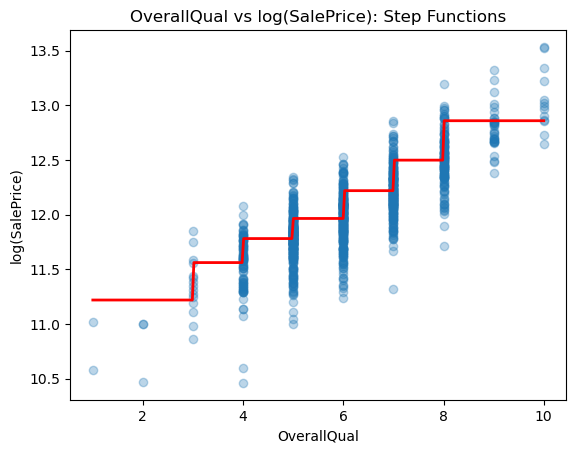

In [31]:
qual_range = np.linspace(1, 10, 300)
qual_range_cut = pd.cut(qual_range, bins=bins)
qual_range_step = pd.get_dummies(qual_range_cut, drop_first=True)

plt.scatter(X_train_qual, y_train, alpha=0.3)
plt.plot(qual_range, model_step_qual.predict(qual_range_step), color='red', linewidth=2)
plt.xlabel('OverallQual')
plt.ylabel('log(SalePrice)')
plt.title('OverallQual vs log(SalePrice): Step Functions')
plt.show()

Step functions capture the stepwise nature of `OverallQual` naturally: each bin corresponds directly to a quality rating group, and the curve closely follows the data.
    
The bin boundaries align with the actual discrete values of this feature, so no information is lost at the edges. 
    
Interpretability is high: each step has a direct meaning.

### `OverallQual` vs `SalePrice`: Regression Splines

In [32]:
# Select the optimal number of knots

results_splines_qual = []

for n_knots in [3, 4, 5, 6, 7]:
    spline = SplineTransformer(n_knots=n_knots, degree=3, include_bias=False)\
    
    X_train_spline = spline.fit_transform(X_train_qual)
    X_val_spline = spline.transform(X_val_qual)
    
    model_spline = LinearRegression()
    model_spline.fit(X_train_spline, y_train)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, model_spline.predict(X_train_spline)))
    val_rmse = np.sqrt(mean_squared_error(y_val, model_spline.predict(X_val_spline)))
    
    results_splines_qual.append({
        'n_knots': n_knots,
        'Train RMSE': train_rmse,
        'Validation RMSE': val_rmse,
        'Gap': val_rmse - train_rmse
    })

pd.DataFrame(results_splines_qual).style.format('{:.4f}', subset=['Train RMSE', 'Validation RMSE', 'Gap']).hide(axis='index')

n_knots,Train RMSE,Validation RMSE,Gap
3,0.2246,0.2336,0.0090
4,0.2244,0.2332,0.0089
5,0.2242,0.2334,0.0092
6,0.2241,0.2334,0.0093
7,0.2241,0.2335,0.0094


> n_knots=4 gives the best validation RMSE (0.2332) and the smallest gap (0.0089). Higher values of n_knots increase overfitting without improving validation performance.

In [33]:
spline_qual_train_rmse = 0.2244
spline_qual_val_rmse = 0.2332
spline_qual_gap = 0.0089

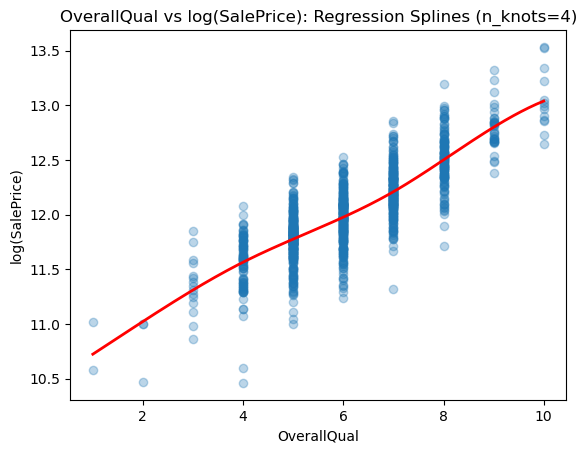

In [34]:
spline_qual = SplineTransformer(n_knots=4, degree=3, include_bias=False)
X_train_spline_qual = spline_qual.fit_transform(X_train_qual)

model_spline_qual = LinearRegression()
model_spline_qual.fit(X_train_spline_qual, y_train)

qual_range = np.linspace(1, 10, 300).reshape(-1, 1)
qual_range_df = pd.DataFrame(qual_range, columns=['OverallQual'])

plt.scatter(X_train_qual, y_train, alpha=0.3)
plt.plot(qual_range_df['OverallQual'], model_spline_qual.predict(spline_qual.transform(qual_range_df)), color='red', linewidth=2)
plt.xlabel('OverallQual')
plt.ylabel('log(SalePrice)')
plt.title('OverallQual vs log(SalePrice): Regression Splines (n_knots=4)')
plt.show()

Regression splines produce a smooth curve that captures the general upward trend. However, as with polynomial regression, a continuous curve is semantically misleading for a discrete ordinal feature: the curve implies that `OverallQual` values like 4.5 or 7.3 are meaningful, which they are not. 

Discussing interpretability of the spline curve does not make sense since the model predicts prices for values that do not exist in the data.

### `OverallQual`: Method Comparison

In [35]:
summary_qual = pd.DataFrame([
    {
        'Method': 'Polynomial (degree=2)',
        'Train RMSE': poly_qual_train_rmse,
        'Validation RMSE': poly_qual_val_rmse,
        'Gap': poly_qual_gap
    },
    {
        'Method': 'Step Functions',
        'Train RMSE': step_qual_train_rmse,
        'Validation RMSE':step_qual_val_rmse,
        'Gap': step_qual_gap
    },
    {
        'Method': 'Splines (n_knots=4)',
        'Train RMSE': spline_qual_train_rmse,
        'Validation RMSE': spline_qual_val_rmse,
        'Gap': spline_qual_gap
    },
])

summary_qual.style.format('{:.4f}', subset=['Train RMSE', 'Validation RMSE', 'Gap']).hide(axis='index')

Method,Train RMSE,Validation RMSE,Gap
Polynomial (degree=2),0.2254,0.2336,0.0081
Step Functions,0.2272,0.2333,0.0061
Splines (n_knots=4),0.2244,0.2332,0.0089


For `OverallQual`, Splines (n_knots=4) and step functions achieve virtually identical validation RMSE (0.2332 vs 0.2333). 
    
However, Step Functions have a significantly smaller gap (0.0061 vs 0.0089), indicating better generalization. 
        
More importantly, `OverallQual` is a discrete ordinal feature, meaning the data is already stepwise by nature, so **step functions** are the most natural representation. 

## `TotalBsmtSF` vs `SalePrice`

In [36]:
X_train_bsmt = X_train[['TotalBsmtSF']]
X_val_bsmt = X_val[['TotalBsmtSF']]

print(X_train_bsmt['TotalBsmtSF'].describe())

count    1166.000000
mean     1061.599485
std       419.075088
min         0.000000
25%       804.000000
50%      1008.000000
75%      1310.750000
max      3200.000000
Name: TotalBsmtSF, dtype: float64


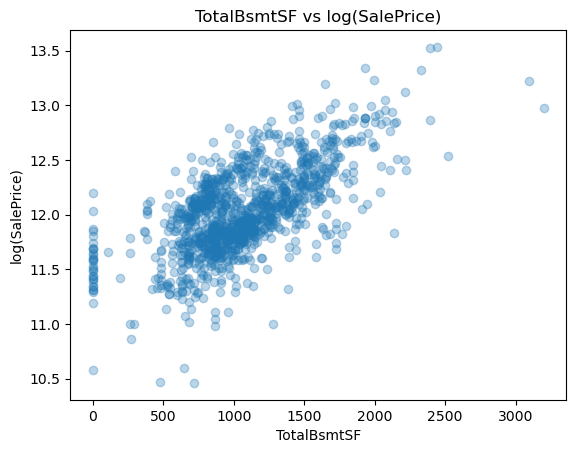

In [37]:
plt.scatter(X_train_bsmt, y_train, alpha=0.3)
plt.xlabel('TotalBsmtSF')
plt.ylabel('log(SalePrice)')
plt.title('TotalBsmtSF vs log(SalePrice)')
plt.show()

### `TotalBsmtSF` vs `SalePrice`: Polynomial Regression

In [38]:
results_bsmt = []

for degree in [2, 3, 4, 5]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    
    X_train_poly = poly.fit_transform(X_train_bsmt)
    X_val_poly = poly.transform(X_val_bsmt)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train_poly)))
    val_rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val_poly)))
    
    results_bsmt.append({
        'Degree': degree,
        'Train RMSE': train_rmse,
        'Validation RMSE':val_rmse,
        'Gap': val_rmse - train_rmse
    })

pd.DataFrame(results_bsmt).style.format('{:.4f}', subset=['Train RMSE', 'Validation RMSE', 'Gap']).hide(axis='index')

Degree,Train RMSE,Validation RMSE,Gap
2,0.3016,0.3152,0.0136
3,0.3005,0.3103,0.0097
4,0.3005,0.3097,0.0092
5,0.3002,0.3092,0.0090


Validation RMSE improves with degree but the gains are diminishing: the largest drop is between degrees 2 and 3 (0.3152 to 0.3103), while degrees 4 and 5 are nearly identical (0.3097 vs 0.3092).

Adding complexity without a meaningful improvement in performance is not desirable, so a visual comparison will help decide whether degree 5 is actually capturing a real pattern or just overfitting.

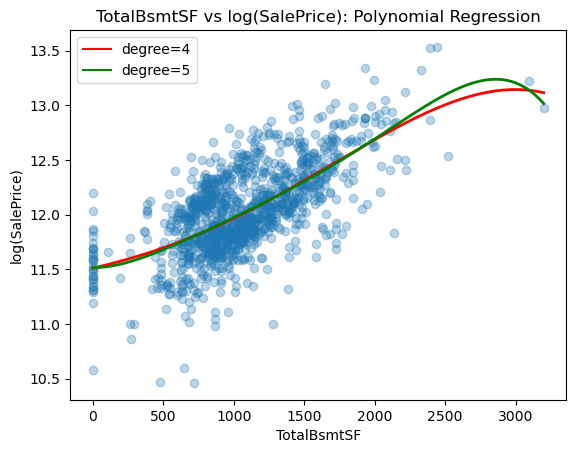

In [39]:
bsmt_range = np.linspace(0, 3200, 300).reshape(-1, 1)
bsmt_range_df = pd.DataFrame(bsmt_range, columns=['TotalBsmtSF'])

plt.scatter(X_train_bsmt, y_train, alpha=0.3)

for degree, color in [(4, 'red'), (5, 'green')]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_bsmt)
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    plt.plot(bsmt_range_df['TotalBsmtSF'],
             model.predict(poly.transform(bsmt_range_df)),
             color=color, linewidth=2)

plt.xlabel('TotalBsmtSF')
plt.ylabel('log(SalePrice)')
plt.title('TotalBsmtSF vs log(SalePrice): Polynomial Regression')
plt.legend(handles=[
    Line2D([0], [0], color='red', label='degree=4'),
    Line2D([0], [0], color='green', label='degree=5')
])
plt.show()

Both curves fit the main data range (500–2000) well. However, the right tail (2500+) contains very few observations, and both polynomials extrapolate unreliably in that range.
    
Degree 5 shows a notable hump after 2500 where data is sparse — this may indicate overfitting to a few points rather than capturing a real pattern. Degree 4 follows the data more closely without chasing sparse outliers and is therefore the preferred choice.

Interpretability is moderate: the curve shows a clear upward trend with a diminishing rate of growth, which is intuitive — each additional square foot adds less value as the basement gets larger. However, the behavior in the 2500+ range is unreliable due to sparse data, so predictions for very large basements should be treated with caution.

In [40]:
# RMSE for degree 4 polynomial
poly_bsmt_train_rmse = 0.3005
poly_bsmt_val_rmse = 0.3097
poly_bsmt_gap = 0.0092

### `TotalBsmtSF` vs `SalePrice`: Step Functions

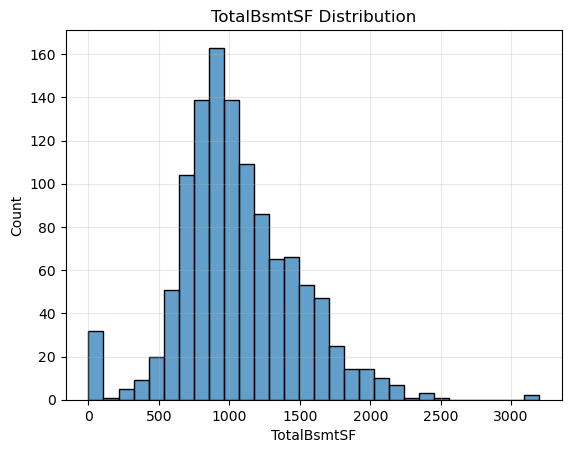

In [41]:
# TotalBsmtSF distribution
sns.histplot(X_train_bsmt, x='TotalBsmtSF', bins=30, alpha=0.7)
plt.title('TotalBsmtSF Distribution')
plt.grid(True, alpha=0.3)

Step functions are applied here for the sake of completeness, as the project requires comparing all three methods. 

However, `TotalBsmtSF` is a continuous feature with a roughly normal distribution. There are no natural breakpoints that would make binning meaningful. Unlike `OverallQual`, where discrete values aligned naturally with bins, any boundaries here will be arbitrary.

In [42]:
X_train_bsmt['TotalBsmtSF'].value_counts()

TotalBsmtSF
0       31
864     28
672     13
912     12
816     11
        ..
958      1
2078     1
1722     1
2077     1
622      1
Name: count, Length: 643, dtype: int64

There are 31 homes with no basement. They form a meaningful separate group which should not be merged with small basements. 

A dedicated bin for zero values preserves this information. The remaining homes are split into equal-width intervals of 500 sqft up to 2000, with a final bin for larger basements (2000+) due to sparse data in that range.

In [43]:
bins = [-1, 0, 500, 1000, 1500, 2000, 3200]

X_train_cut_bsmt = pd.cut(X_train_bsmt['TotalBsmtSF'], bins=bins)
print(X_train_cut_bsmt.value_counts().sort_index())

TotalBsmtSF
(-1, 0]          31
(0, 500]         29
(500, 1000]     516
(1000, 1500]    422
(1500, 2000]    142
(2000, 3200]     26
Name: count, dtype: int64


In [44]:
X_val_cut_bsmt = pd.cut(X_val_bsmt['TotalBsmtSF'], bins=bins)

X_train_step_bsmt = pd.get_dummies(X_train_cut_bsmt, drop_first=True)
X_val_step_bsmt = pd.get_dummies(X_val_cut_bsmt, drop_first=True)

model_step_bsmt = LinearRegression()
model_step_bsmt.fit(X_train_step_bsmt, y_train)

step_bsmt_train_rmse = np.sqrt(mean_squared_error(y_train, model_step_bsmt.predict(X_train_step_bsmt)))
step_bsmt_val_rmse = np.sqrt(mean_squared_error(y_val, model_step_bsmt.predict(X_val_step_bsmt)))
step_bsmt_gap = step_bsmt_val_rmse - step_bsmt_train_rmse

print(f'Step Functions')
print(f'Train RMSE: {step_bsmt_train_rmse:.4f}')
print(f'Validation RMSE: {step_bsmt_val_rmse:.4f}')
print(f'Gap: {step_bsmt_gap:.4f}')

Step Functions
Train RMSE: 0.3144
Validation RMSE: 0.3257
Gap: 0.0113


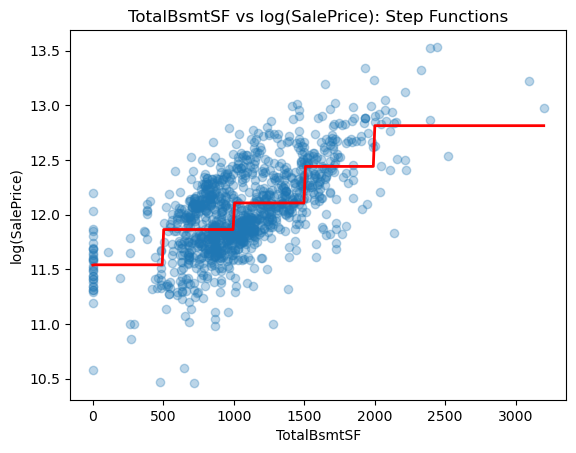

In [45]:
bsmt_range = np.linspace(0, 3200, 300)
bsmt_range_cut = pd.cut(bsmt_range, bins=bins)
bsmt_range_step = pd.get_dummies(bsmt_range_cut, drop_first=True)

plt.scatter(X_train_bsmt, y_train, alpha=0.3)
plt.plot(bsmt_range, model_step_bsmt.predict(bsmt_range_step), color='red', linewidth=2)
plt.xlabel('TotalBsmtSF')
plt.ylabel('log(SalePrice)')
plt.title('TotalBsmtSF vs log(SalePrice): Step Functions')
plt.show()

In [46]:
# Verify that homes without a basement are handled as a distinct category
model_step_bsmt.predict(X_train_step_bsmt[X_train_bsmt['TotalBsmtSF'] == 0])[:5]

array([11.53831644, 11.53831644, 11.53831644, 11.53831644, 11.53831644])

Step functions capture the general upward trend, but lose detail within each bin, especially in the (500, 1500] range where most observations are concentrated.
    
Interpretability is limited: each bin has a direct meaning in isolation, but the boundaries are arbitrary and do not reflect any natural breakpoints in the data. The no-basement group is an exception — it has a clear semantic meaning, but it is not visible on the plot, which makes visual assessment of this group impossible.

### `OverallQual` vs `SalePrice`: Regression Splines

In [47]:
# Select the optimal number of knots

results_splines_bsmt = []

for n_knots in [3, 4, 5, 6, 7]:
    spline = SplineTransformer(n_knots=n_knots, degree=3, include_bias=False)
    
    X_train_spline = spline.fit_transform(X_train_bsmt)
    X_val_spline = spline.transform(X_val_bsmt)
    
    model_spline = LinearRegression()
    model_spline.fit(X_train_spline, y_train)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, model_spline.predict(X_train_spline)))
    val_rmse = np.sqrt(mean_squared_error(y_val, model_spline.predict(X_val_spline)))
    
    results_splines_bsmt.append({
        'n_knots': n_knots,
        'Train RMSE': train_rmse,
        'Validation RMSE': val_rmse,
        'Gap': val_rmse - train_rmse
    })

pd.DataFrame(results_splines_bsmt).style.format('{:.4f}', subset=['Train RMSE', 'Validation RMSE', 'Gap']).hide(axis='index')

n_knots,Train RMSE,Validation RMSE,Gap
3,0.3004,0.3096,0.0092
4,0.3003,0.3093,0.0089
5,0.3001,0.3094,0.0093
6,0.2999,0.3095,0.0097
7,0.2997,0.3099,0.0102


> n_knots=4 gives the best validation RMSE (0.3093) and the smallest gap (0.0089). Higher values increase overfitting without improving performance.

In [48]:
spline_bsmt_train_rmse = 0.3003
spline_bsmt_val_rmse = 0.3093
spline_bsmt_gap = 0.0089

In [49]:
spline_bsmt = SplineTransformer(n_knots=4, degree=3, include_bias=False)
X_train_spline_bsmt = spline_bsmt.fit_transform(X_train_bsmt)

model_spline_bsmt = LinearRegression()
model_spline_bsmt.fit(X_train_spline_bsmt, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


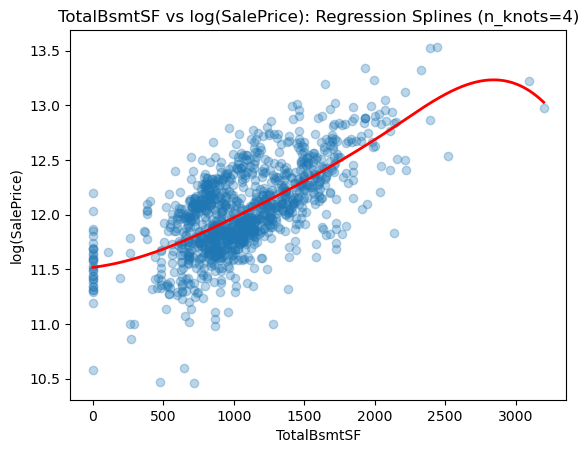

In [50]:
bsmt_range = np.linspace(0, 3200, 300).reshape(-1, 1)
bsmt_range_df = pd.DataFrame(bsmt_range, columns=['TotalBsmtSF'])

plt.scatter(X_train_bsmt, y_train, alpha=0.3)
plt.plot(bsmt_range_df['TotalBsmtSF'], model_spline_bsmt.predict(spline_bsmt.transform(bsmt_range_df)), color='red', linewidth=2)
plt.xlabel('TotalBsmtSF')
plt.ylabel('log(SalePrice)')
plt.title('TotalBsmtSF vs log(SalePrice): Regression Splines (n_knots=4)')
plt.show()

The spline curve captures the general upward trend with diminishing growth, which aligns well with the main data range (500–1500). Structural zeros are not separately handled: they blend into the left edge of the curve, which may affect predictions for homes without a basement. On the right (2000+), sparse data causes the curve to behave erratically. 

Interpretability is moderate: the curve is easy to read in the main range, but the behavior at both ends requires caution. Predictions for homes without a basement and for small basements are likely to have higher errors than predictions in the main data range.

### `TotalBsmtSF`: Method Comparison

In [51]:
summary_bsmt = pd.DataFrame([
    {
        'Method': 'Polynomial (degree=4)',
        'Train RMSE': poly_bsmt_train_rmse,
        'Validation RMSE': poly_bsmt_val_rmse,
        'Gap': poly_bsmt_gap
    },
    {
        'Method': 'Step Functions',
        'Train RMSE': step_bsmt_train_rmse,
        'Validation RMSE': step_bsmt_val_rmse,
        'Gap': step_bsmt_gap
    },
    {
        'Method': 'Splines (n_knots=4)',
        'Train RMSE': spline_bsmt_train_rmse,
        'Validation RMSE': spline_bsmt_val_rmse,
        'Gap': spline_bsmt_gap
    },
])

pd.DataFrame(summary_bsmt).style.format('{:.4f}', subset=['Train RMSE', 'Validation RMSE', 'Gap']).hide(axis='index')

Method,Train RMSE,Validation RMSE,Gap
Polynomial (degree=4),0.3005,0.3097,0.0092
Step Functions,0.3144,0.3257,0.0113
Splines (n_knots=4),0.3003,0.3093,0.0089


> Splines (n_knots=4) achieve the best validation RMSE (0.3093) and the smallest gap (0.0089), outperforming both polynomial regression and step functions. 
    
However, RMSE reflects average performance across all observations. Since most data is concentrated in the 500–1500 range, the metric does not capture the unreliable behavior at both ends. The same pattern was observed for `HouseAge`, where the curve became unstable after 100 years.

## Results and Conclusions

In [52]:
linear_rmse = {}

for feature, X_train_f, X_val_f in [
    ('HouseAge', X_train_age, X_val_age),
    ('OverallQual', X_train_qual, X_val_qual),
    ('TotalBsmtSF', X_train_bsmt, X_val_bsmt)
]:
    poly = PolynomialFeatures(degree=1, include_bias=False)
    model = LinearRegression()
    model.fit(poly.fit_transform(X_train_f), y_train)
    linear_rmse[feature] = np.sqrt(mean_squared_error(y_val, model.predict(poly.transform(X_val_f))))

best_method = {
    'HouseAge': 'Splines (n_knots=6)',
    'OverallQual': 'Step Functions',
    'TotalBsmtSF': 'Splines (n_knots=4)'
}

best_nonlinear = {
    'HouseAge': min(poly_age_val_rmse, step_age_val_rmse, spline_age_val_rmse),
    'OverallQual': min(poly_qual_val_rmse, step_qual_val_rmse, spline_qual_val_rmse),
    'TotalBsmtSF': min(poly_bsmt_val_rmse, step_bsmt_val_rmse, spline_bsmt_val_rmse)
}

results_comparison = pd.DataFrame([
    {
        'Feature': feature,
        'Linear RMSE': linear_rmse[feature],
        'Best Nonlinear RMSE': best_nonlinear[feature],
        'Improvement':linear_rmse[feature] - best_nonlinear[feature],
        'Best Method': best_method[feature]
    }
    for feature in linear_rmse
])

pd.DataFrame(results_comparison).style.format('{:.4f}', subset=['Linear RMSE', 'Best Nonlinear RMSE', 'Improvement']).hide(axis='index')

Feature,Linear RMSE,Best Nonlinear RMSE,Improvement,Best Method
HouseAge,0.3258,0.3090,0.0168,Splines (n_knots=6)
OverallQual,0.2340,0.2332,0.0008,Step Functions
TotalBsmtSF,0.3123,0.3093,0.0030,Splines (n_knots=4)


* `HouseAge` benefited most from nonlinear modeling: *splines* reduced validation RMSE by 0.0168 compared to a linear baseline, capturing the U-shaped relationship that a straight line cannot represent. 
    
* For `TotalBsmtSF`, the improvement was more modest (0.0030), as the relationship is closer to linear in the main data range.
    
* `OverallQual` showed almost no improvement (0.0008) since the relationship is already nearly linear on the log scale, and the small gain from step functions reflects the natural stepwise structure of the feature rather than a nonlinear pattern.

* **Splines** performed best for both continuous features, while **step functions** were the preferred choice for the discrete ordinal feature.

* In terms of accuracy, splines achieved the lowest validation RMSE for continuous features (`HouseAge` and `TotalBsmtSF`). For `OverallQual`, all three methods performed similarly, so step functions were preferred not for accuracy, but because they align naturally with the discrete nature of the feature.

* In terms of interpretability, all three methods are readable through visualization.

    - Step functions offer the most direct explanation: each bin has a concrete meaning.
    - Polynomial regression provides interpretable coefficients.
    - Splines are the least transparent in terms of coefficients, but produce the most visually intuitive curve. This trade-off makes them a strong practical choice when accuracy matters more than mathematical explainability.

## Applying Best Transformations to the Baseline Model

Based on the per-feature analysis, `HouseAge` showed the largest improvement from nonlinear modeling (0.0168), followed by `TotalBsmtSF` (0.0030). 
    
`OverallQual` showed a negligible improvement (0.0008) — the relationship is already nearly linear on the log scale, and the complexity of adding step function dummy variables to the pipeline is not justified by such a small gain.
    
Therefore, only spline transformations for `HouseAge` and `TotalBsmtSF` are integrated into the final Lasso pipeline.

In [53]:
import joblib
import pickle
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

ARTIFACTS_PATH = ROOT / 'artifacts'

# Load pipeline components
numeric_median_pipeline = joblib.load(ARTIFACTS_PATH / 'numeric_median_pipeline.pkl')
numeric_zero_pipeline = joblib.load(ARTIFACTS_PATH / 'numeric_zero_pipeline.pkl')
cat_no_feature_pipeline = joblib.load(ARTIFACTS_PATH / 'cat_no_feature_pipeline.pkl')
cat_truly_missing_pipeline = joblib.load(ARTIFACTS_PATH / 'cat_truly_missing_pipeline.pkl')
cat_no_missing_pipeline = joblib.load(ARTIFACTS_PATH / 'cat_no_missing_pipeline.pkl')

# Load column lists
with open(ARTIFACTS_PATH / 'column_lists.pkl', 'rb') as f:
    column_lists = pickle.load(f)

num_fill_with_zero = column_lists['num_fill_with_zero']
num_fill_with_median = column_lists['num_fill_with_median']
cat_no_feature = column_lists['cat_no_feature']
cat_truly_missing = column_lists['cat_truly_missing']
cat_no_missing = column_lists['cat_no_missing']
num_features = column_lists['num_features']

In [54]:
num_fill_with_zero = [col for col in column_lists['num_fill_with_zero'] 
                      if col != 'TotalBsmtSF']

In [55]:
num_fill_with_median = [col for col in num_fill_with_median 
                        if col not in ['HouseAge', 'TotalBsmtSF']]

In [56]:
spline_age_pipeline = Pipeline([
    ('spline', SplineTransformer(n_knots=6, degree=3, include_bias=False)),
    ('scaler', StandardScaler())
])

spline_bsmt_pipeline = Pipeline([
    ('imputer', SimpleImputer(fill_value=0, strategy='constant')),
    ('spline', SplineTransformer(n_knots=4, degree=3, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('numeric_median', numeric_median_pipeline, num_fill_with_median),
    ('numeric_zero', numeric_zero_pipeline, num_fill_with_zero),
    ('cat_no_feature', cat_no_feature_pipeline, cat_no_feature),
    ('cat_truly_missing', cat_truly_missing_pipeline, cat_truly_missing),
    ('cat_no_missing', cat_no_missing_pipeline, cat_no_missing),
    ('spline_age', spline_age_pipeline, ['HouseAge']),
    ('spline_bsmt', spline_bsmt_pipeline, ['TotalBsmtSF'])
])

In [57]:
import warnings

pipeline_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LassoCV(cv=5, max_iter=10000, random_state=123))
])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=123)

# UserWarning about unknown categories is expected when predicting on unseen data
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    pipeline_cv.fit(X_train, y_train)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, pipeline_cv.predict(X_train)))
    val_rmse = np.sqrt(mean_squared_error(y_val, pipeline_cv.predict(X_val)))
    gap = val_rmse - train_rmse

print(f'Best alpha: {pipeline_cv.named_steps["model"].alpha_:.6f}')
print(f'Train RMSE: {train_rmse:.4f}')
print(f'Validation RMSE: {val_rmse:.4f}')
print(f'Gap: {gap:.4f}')

Best alpha: 0.000762
Train RMSE: 0.1043
Validation RMSE: 0.1150
Gap: 0.0107


In [58]:
comparison = pd.DataFrame([
    {'Model': 'Lasso baseline (α=0.00066)', 'Train RMSE': BASELINE_RESULTS['Train RMSE'], 
     'Validation RMSE': BASELINE_RESULTS['Validation RMSE'], 'Gap': BASELINE_RESULTS['Gap']},
    {'Model': 'Lasso (α=0.000762) + Splines', 'Train RMSE': train_rmse, 
     'Validation RMSE': val_rmse, 'Gap': gap},
])

comparison.style.format('{:.4f}', subset=['Train RMSE', 'Validation RMSE', 'Gap']).hide(axis='index')

Model,Train RMSE,Validation RMSE,Gap
Lasso baseline (α=0.00066),0.1040,0.1160,0.0120
Lasso (α=0.000762) + Splines,0.1043,0.1150,0.0107


## Final Conclusion
Applying spline transformations to `HouseAge` and `TotalBsmtSF` improved the baseline Lasso model from 0.1160 to 0.1150 validation RMSE. 
    
Re-tuning alpha via LassoCV yielded `α=0.000762` and further reduced the gap from 0.0120 to 0.0107, indicating better generalization.
    
The improvement is modest: in a model with 83 active features, transforming two mid-importance predictors has a limited global impact. 

The most meaningful outcome of this project is not the metric improvement, but the understanding of how nonlinear transformations apply to different feature types: which features benefit from splines, which are already well-served by a linear relationship, and where the added complexity is not justified. This understanding informs better preprocessing decisions in future projects.

In [59]:
# Export the pipeline
joblib.dump(pipeline_cv, ARTIFACTS_PATH / 'lasso_splines_pipeline.pkl')

updated_cols_splines = {
    'num_fill_with_zero': num_fill_with_zero,
    'num_fill_with_median': num_fill_with_median,
    'cat_no_feature': cat_no_feature,
    'cat_truly_missing': cat_truly_missing,
    'cat_no_missing': cat_no_missing,
    'num_features': num_features
}

with open(ARTIFACTS_PATH / 'column_lists_splines.pkl', 'wb') as f:
    pickle.dump(updated_cols_splines, f)